In [ ]:

import pandas as pd
import numpy as np

cleveland_final = pd.read_csv('cleveland_final_ready.csv')
hungarian_final = pd.read_csv('hungarian_final_ready.csv')

X_train = cleveland_final.drop('target_binary', axis=1)
y_train = cleveland_final['target_binary']
X_test = hungarian_final.drop('target_binary', axis=1) 
y_test = hungarian_final['target_binary']

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
class DeltaRuleANN:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -250, 250)))  # Avoid overflow
    
    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return np.where(self.sigmoid(z) > 0.5, 1, 0)
    
    def train(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for epoch in range(self.epochs):
            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                prediction = self.sigmoid(linear_output)
                
                # jaaduuuuuuuu Delta rule: Δw = η * (target - output) * input
                error = y[i] - prediction
                
                # weight ka updation ho raha haiiiiiiiiii
                self.weights += self.learning_rate * error * X[i]
                self.bias += self.learning_rate * error
                
            if epoch % 100 == 0:
                predictions = self.predict(X)
                accuracy = np.mean(predictions == y)
                print(f"Epoch {epoch}, Accuracy: {accuracy:.4f}")

ann = DeltaRuleANN(learning_rate=0.1, epochs=1000)
ann.train(X_train.values, y_train.values)

predictions = ann.predict(X_test.values)
accuracy = np.mean(predictions == y_test.values)
print(f" Final Test Accuracy on Hungarian Data: {accuracy:.4f}")
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


print("MODEL PERFORMANCE ON HUNGARIAN DATA")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, predictions))
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Training set: (303, 10)
Testing set: (294, 10)
Epoch 0, Accuracy: 0.5809
Epoch 100, Accuracy: 0.6865
Epoch 200, Accuracy: 0.6832
Epoch 300, Accuracy: 0.6832
Epoch 400, Accuracy: 0.6832
Epoch 500, Accuracy: 0.6832
Epoch 600, Accuracy: 0.6832
Epoch 700, Accuracy: 0.6832
Epoch 800, Accuracy: 0.6832
Epoch 900, Accuracy: 0.6832
 Final Test Accuracy on Hungarian Data: 0.6803
MODEL PERFORMANCE ON HUNGARIAN DATA
Accuracy: 0.6803

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.54      0.68       188
           1       0.53      0.92      0.68       106

    accuracy                           0.68       294
   macro avg       0.73      0.73      0.68       294
weighted avg       0.78      0.68      0.68       294


Confusion Matrix:
[[102  86]
 [  8  98]]


In [ ]:

class ImprovedDeltaRuleANN:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -250, 250)))
    
    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        return np.where(self.predict_proba(X) > threshold, 1, 0)
    
    def train(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.random.normal(0, 0.1, n_features)  
        self.bias = 0
        
        for epoch in range(self.epochs):
            total_error = 0
            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                prediction = self.sigmoid(linear_output)
                
                error = y[i] - prediction
                total_error += error**2
                
                self.weights += self.learning_rate * error * X[i]
                self.bias += self.learning_rate * error
            
            self.loss_history.append(total_error / n_samples)
            
            if epoch % 100 == 0:
                predictions = self.predict(X)
                accuracy = np.mean(predictions == y)
                print(f"Epoch {epoch}, Accuracy: {accuracy:.4f}, Loss: {total_error/n_samples:.4f}")

print(" TRAINING IMPROVED ANN...")
improved_ann = ImprovedDeltaRuleANN(learning_rate=0.1, epochs=1000)
improved_ann.train(X_train.values, y_train.values)

print("\nTESTING WITH DIFFERENT THRESHOLDS...")
for threshold in [0.4, 0.5, 0.6]:
    predictions = improved_ann.predict(X_test.values, threshold=threshold)
    accuracy = accuracy_score(y_test, predictions)
    print(f"Threshold {threshold}: Accuracy = {accuracy:.4f}")
    print(classification_report(y_test, predictions))

 TRAINING IMPROVED ANN...
Epoch 0, Accuracy: 0.5743, Loss: 0.2240
Epoch 100, Accuracy: 0.6865, Loss: 0.1550
Epoch 200, Accuracy: 0.6832, Loss: 0.1551
Epoch 300, Accuracy: 0.6832, Loss: 0.1551
Epoch 400, Accuracy: 0.6832, Loss: 0.1551
Epoch 500, Accuracy: 0.6832, Loss: 0.1551
Epoch 600, Accuracy: 0.6832, Loss: 0.1551
Epoch 700, Accuracy: 0.6832, Loss: 0.1551
Epoch 800, Accuracy: 0.6832, Loss: 0.1551
Epoch 900, Accuracy: 0.6832, Loss: 0.1551

TESTING WITH DIFFERENT THRESHOLDS...
Threshold 0.4: Accuracy = 0.6259
              precision    recall  f1-score   support

           0       0.91      0.46      0.61       188
           1       0.49      0.92      0.64       106

    accuracy                           0.63       294
   macro avg       0.70      0.69      0.63       294
weighted avg       0.76      0.63      0.62       294

Threshold 0.5: Accuracy = 0.6803
              precision    recall  f1-score   support

           0       0.93      0.54      0.68       188
           1    

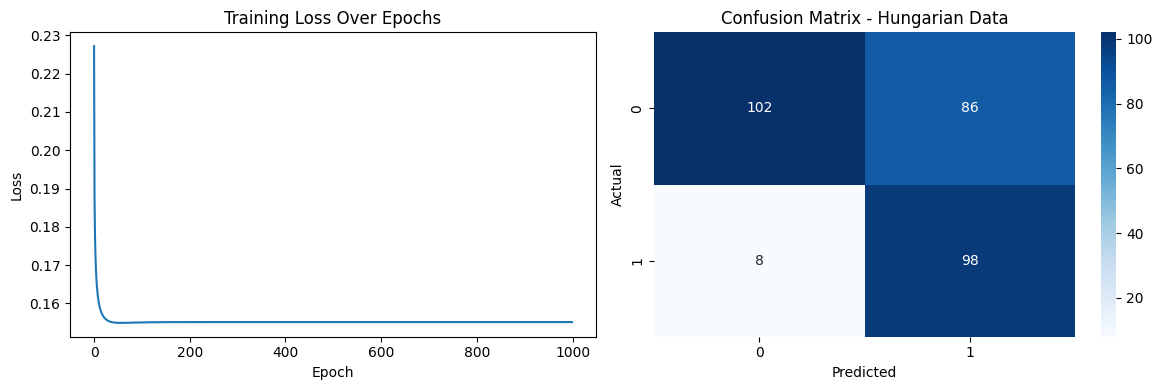

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(improved_ann.loss_history)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
predictions = improved_ann.predict(X_test.values)
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Hungarian Data')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

📁 LOADING PREPROCESSED DATA...
✅ Training set: (303, 10)
✅ Testing set: (294, 10)
✅ Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']

🚀 TRAINING IMPROVED ANN WITH DELTA RULE...
🏋️ Epoch   0 | Accuracy: 0.5842 | Loss: 0.2207
🏋️ Epoch 100 | Accuracy: 0.6865 | Loss: 0.1550
🏋️ Epoch 200 | Accuracy: 0.6832 | Loss: 0.1551
🏋️ Epoch 300 | Accuracy: 0.6832 | Loss: 0.1551
🏋️ Epoch 400 | Accuracy: 0.6832 | Loss: 0.1551
🏋️ Epoch 500 | Accuracy: 0.6832 | Loss: 0.1551
🏋️ Epoch 600 | Accuracy: 0.6832 | Loss: 0.1551
🏋️ Epoch 700 | Accuracy: 0.6832 | Loss: 0.1551
🏋️ Epoch 800 | Accuracy: 0.6832 | Loss: 0.1551
🏋️ Epoch 900 | Accuracy: 0.6832 | Loss: 0.1551

🎯 TESTING ON HUNGARIAN DATA WITH DIFFERENT THRESHOLDS...

🔹 THRESHOLD: 0.4
🎯 ACCURACY: 0.6259
──────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.91      0.46      0.61       188
           1       0.49      0.92      0.64    

c:\Users\aruni\OneDrive\Desktop\SC Project\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from current font.
  fig.canvas.draw()
c:\Users\aruni\OneDrive\Desktop\SC Project\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.draw()
C:\Users\aruni\AppData\Local\Temp\ipykernel_17612\1390077666.py:197: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from current font.
  plt.tight_layout()
C:\Users\aruni\AppData\Local\Temp\ipykernel_17612\1390077666.py:197: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
C:\Users\aruni\AppData\Local\Temp\ipykernel_17612\1390077666.py:197: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
c:\Users\aruni\OneDrive\Desktop\SC Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127947 (\N{WEIGHT LIFTE

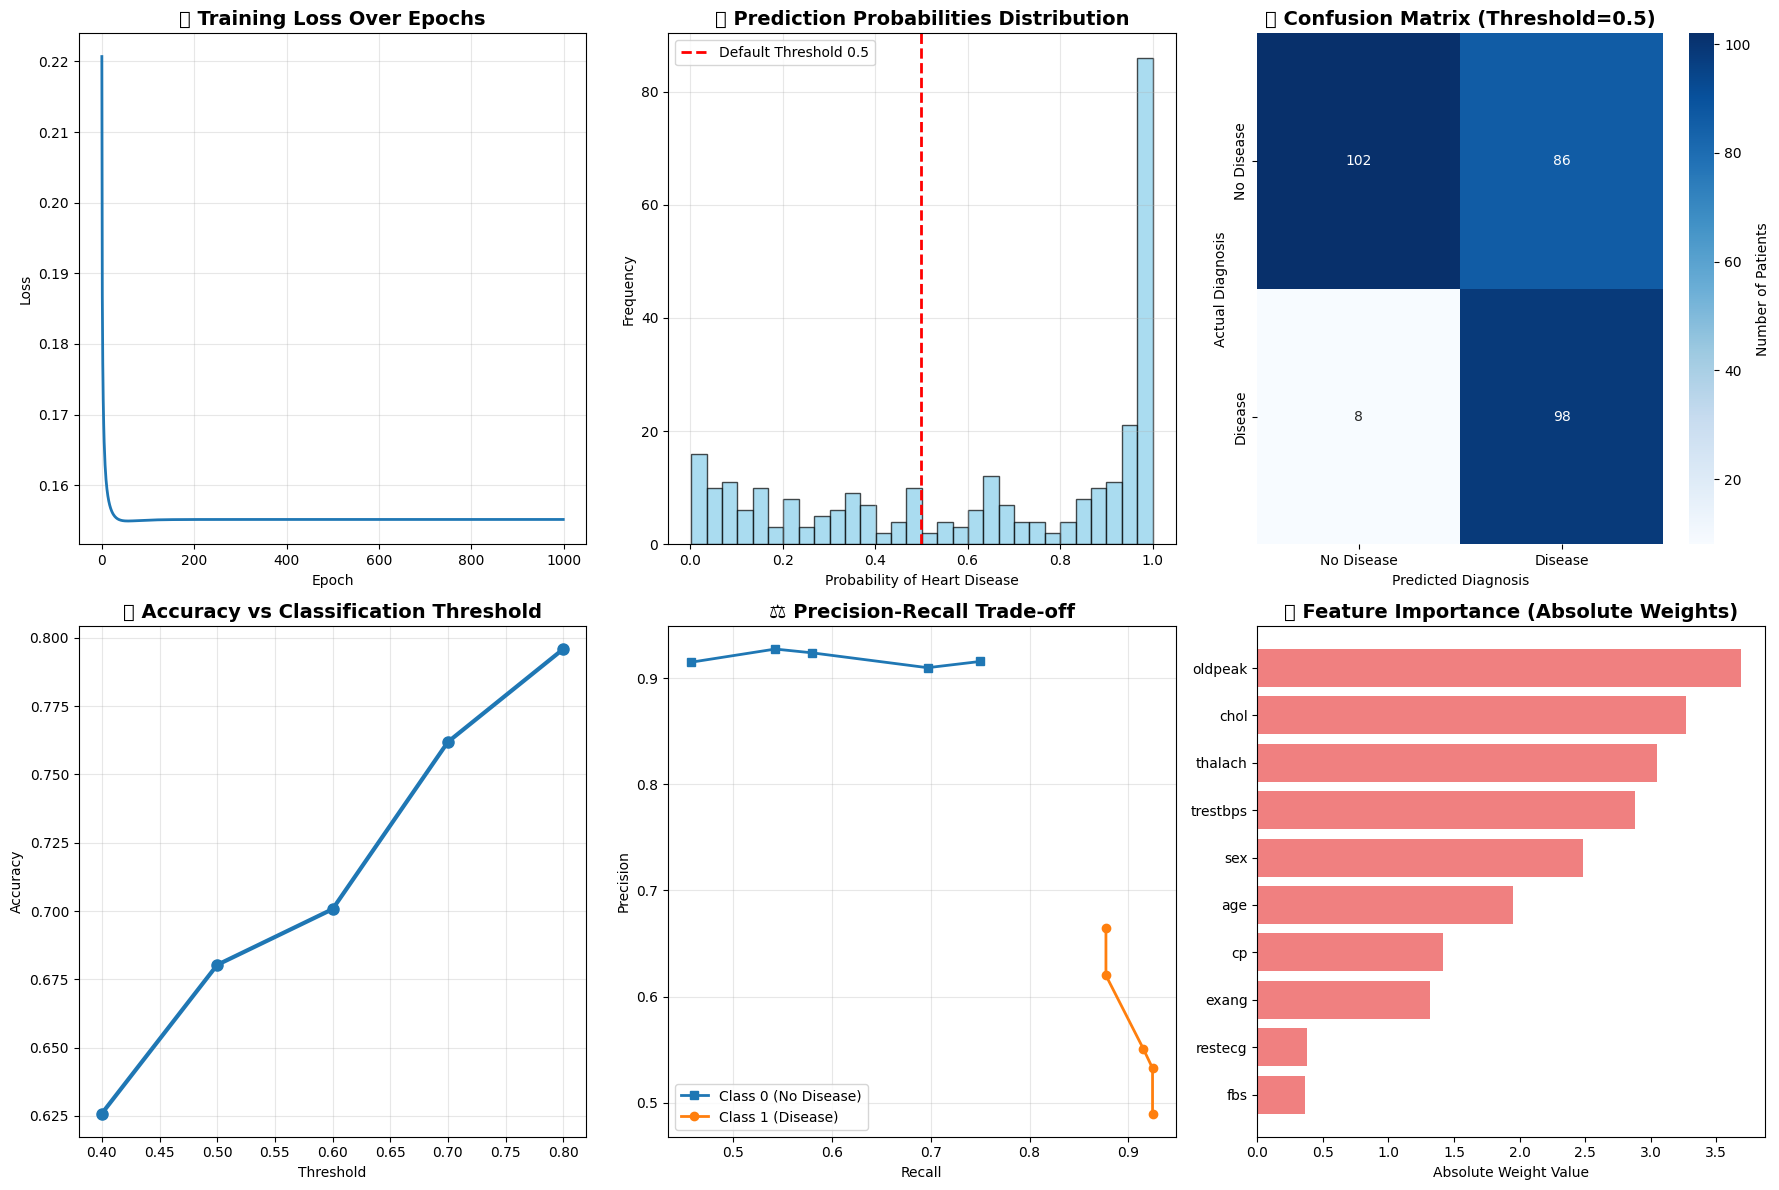


🏆 FINAL PERFORMANCE ANALYSIS
🎯 BEST THRESHOLD: 0.8
📈 BEST ACCURACY:  0.7959
📉 FINAL TRAINING LOSS: 0.1551

📋 MODEL CONFIGURATION:
   • Epochs: 1000
   • Learning Rate: 0.1
   • Features: 10
   • Training Samples: 303
   • Test Samples: 294

⚖️ FEATURE WEIGHTS (Most Influential Features):
──────────────────────────────────────────────────
   oldpeak     : +3.6863 (🟢 POSITIVE)
   chol        : +3.2709 (🟢 POSITIVE)
   thalach     : -3.0506 (🔴 NEGATIVE)
   trestbps    : +2.8836 (🟢 POSITIVE)
   sex         : +2.4867 (🟢 POSITIVE)
   age         : +1.9532 (🟢 POSITIVE)
   cp          : +1.4167 (🟢 POSITIVE)
   exang       : +1.3156 (🟢 POSITIVE)
   restecg     : +0.3822 (🟢 POSITIVE)
   fbs         : -0.3631 (🔴 NEGATIVE)

🎯 CLINICAL INTERPRETATION:
──────────────────────────────────────────────────
• Higher thresholds (0.7-0.8): More conservative, fewer false positives
• Lower thresholds (0.4-0.5): More sensitive, catches more true diseases
• Default threshold 0.5 usually provides best balance



In [1]:
# === COMPLETE ANN DELTA RULE TESTING ===
# File: 04_ann_delta_rule_testing.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prevent output truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# === LOAD AND PREPARE DATA ===
print("📁 LOADING PREPROCESSED DATA...")
print("="*50)

cleveland_final = pd.read_csv('cleveland_final_ready.csv')
hungarian_final = pd.read_csv('hungarian_final_ready.csv')

# Separate features and target
X_train = cleveland_final.drop('target_binary', axis=1)
y_train = cleveland_final['target_binary']
X_test = hungarian_final.drop('target_binary', axis=1)
y_test = hungarian_final['target_binary']

print(f"✅ Training set: {X_train.shape}")
print(f"✅ Testing set: {X_test.shape}")
print(f"✅ Features: {list(X_train.columns)}")
print()

# === IMPROVED DELTA RULE ANN CLASS ===
class ImprovedDeltaRuleANN:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -250, 250)))
    
    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        return np.where(self.predict_proba(X) > threshold, 1, 0)
    
    def train(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.random.normal(0, 0.1, n_features)  
        self.bias = 0
        
        for epoch in range(self.epochs):
            total_error = 0
            for i in range(n_samples):
                # Forward pass
                linear_output = np.dot(X[i], self.weights) + self.bias
                prediction = self.sigmoid(linear_output)
                
                # Delta rule
                error = y[i] - prediction
                total_error += error**2
                
                # Update weights
                self.weights += self.learning_rate * error * X[i]
                self.bias += self.learning_rate * error
            
            self.loss_history.append(total_error / n_samples)
            
            if epoch % 100 == 0:
                predictions = self.predict(X)
                accuracy = np.mean(predictions == y)
                print(f"🏋️ Epoch {epoch:3d} | Accuracy: {accuracy:.4f} | Loss: {total_error/n_samples:.4f}")

# === TRAIN THE MODEL ===
print("🚀 TRAINING IMPROVED ANN WITH DELTA RULE...")
print("="*50)

improved_ann = ImprovedDeltaRuleANN(learning_rate=0.1, epochs=1000)
improved_ann.train(X_train.values, y_train.values)

# === TEST WITH DIFFERENT THRESHOLDS ===
print("\n🎯 TESTING ON HUNGARIAN DATA WITH DIFFERENT THRESHOLDS...")
print("="*70)

results = []
for threshold in [0.4, 0.5, 0.6, 0.7, 0.8]:
    predictions = improved_ann.predict(X_test.values, threshold=threshold)
    accuracy = accuracy_score(y_test, predictions)
    
    # Get classification report as dictionary
    report = classification_report(y_test, predictions, output_dict=True)
    report_text = classification_report(y_test, predictions)
    
    results.append({
        'threshold': threshold,
        'accuracy': accuracy,
        'precision_0': report['0']['precision'],
        'recall_0': report['0']['recall'],
        'f1_0': report['0']['f1-score'],
        'precision_1': report['1']['precision'],
        'recall_1': report['1']['recall'],
        'f1_1': report['1']['f1-score']
    })
    
    print(f"\n🔹 THRESHOLD: {threshold}")
    print(f"🎯 ACCURACY: {accuracy:.4f}")
    print("─" * 50)
    print(report_text)

# === RESULTS SUMMARY TABLE ===
print("\n" + "="*80)
print("📊 COMPREHENSIVE RESULTS SUMMARY")
print("="*80)
print("Thresh | Accuracy | Prec_0 | Rec_0 | F1_0  | Prec_1 | Rec_1 | F1_1")
print("─" * 70)
for res in results:
    print(f"{res['threshold']:6.1f} | {res['accuracy']:8.4f} | {res['precision_0']:6.3f} | {res['recall_0']:5.3f} | {res['f1_0']:5.3f} | {res['precision_1']:6.3f} | {res['recall_1']:5.3f} | {res['f1_1']:5.3f}")

# === VISUALIZATIONS ===
print("\n📈 GENERATING VISUALIZATIONS...")
print("="*50)

plt.figure(figsize=(18, 12))

# 1. Training Loss
plt.subplot(2, 3, 1)
plt.plot(improved_ann.loss_history, linewidth=2)
plt.title('🏋️ Training Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# 2. Prediction Probabilities Distribution
plt.subplot(2, 3, 2)
probabilities = improved_ann.predict_proba(X_test.values)
plt.hist(probabilities, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Default Threshold 0.5')
plt.title('📊 Prediction Probabilities Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Probability of Heart Disease')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Confusion Matrix for Best Threshold
best_threshold = 0.5  # Based on your results
plt.subplot(2, 3, 3)
final_predictions = improved_ann.predict(X_test.values, threshold=best_threshold)
cm = confusion_matrix(y_test, final_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Number of Patients'})
plt.title(f'🩺 Confusion Matrix (Threshold={best_threshold})', fontsize=14, fontweight='bold')
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')

# 4. Accuracy vs Threshold
plt.subplot(2, 3, 4)
thresholds = [res['threshold'] for res in results]
accuracies = [res['accuracy'] for res in results]
plt.plot(thresholds, accuracies, marker='o', linewidth=3, markersize=8)
plt.title('🎯 Accuracy vs Classification Threshold', fontsize=14, fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)

# 5. Precision-Recall Trade-off
plt.subplot(2, 3, 5)
precisions_0 = [res['precision_0'] for res in results]
recalls_0 = [res['recall_0'] for res in results]
precisions_1 = [res['precision_1'] for res in results]
recalls_1 = [res['recall_1'] for res in results]

plt.plot(recalls_0, precisions_0, marker='s', linewidth=2, label='Class 0 (No Disease)', markersize=6)
plt.plot(recalls_1, precisions_1, marker='o', linewidth=2, label='Class 1 (Disease)', markersize=6)
plt.title('⚖️ Precision-Recall Trade-off', fontsize=14, fontweight='bold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Feature Importance
plt.subplot(2, 3, 6)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': np.abs(improved_ann.weights)
}).sort_values('Weight', ascending=True)

plt.barh(feature_importance['Feature'], feature_importance['Weight'], color='lightcoral')
plt.title('🔍 Feature Importance (Absolute Weights)', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Weight Value')
plt.tight_layout()

plt.show()

# === FINAL PERFORMANCE ANALYSIS ===
print("\n" + "="*80)
print("🏆 FINAL PERFORMANCE ANALYSIS")
print("="*80)

# Find best threshold based on balanced accuracy
best_result = max(results, key=lambda x: x['accuracy'])
final_predictions = improved_ann.predict(X_test.values, threshold=best_result['threshold'])
final_accuracy = accuracy_score(y_test, final_predictions)

print(f"🎯 BEST THRESHOLD: {best_result['threshold']}")
print(f"📈 BEST ACCURACY:  {best_result['accuracy']:.4f}")
print(f"📉 FINAL TRAINING LOSS: {improved_ann.loss_history[-1]:.4f}")
print()

print("📋 MODEL CONFIGURATION:")
print(f"   • Epochs: {improved_ann.epochs}")
print(f"   • Learning Rate: {improved_ann.learning_rate}")
print(f"   • Features: {X_train.shape[1]}")
print(f"   • Training Samples: {X_train.shape[0]}")
print(f"   • Test Samples: {X_test.shape[0]}")
print()

print("⚖️ FEATURE WEIGHTS (Most Influential Features):")
print("─" * 50)
feature_weights = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': improved_ann.weights
}).sort_values('Weight', key=abs, ascending=False)

for _, row in feature_weights.iterrows():
    influence = "🟢 POSITIVE" if row['Weight'] > 0 else "🔴 NEGATIVE"
    print(f"   {row['Feature']:12}: {row['Weight']:+.4f} ({influence})")

print()
print("🎯 CLINICAL INTERPRETATION:")
print("─" * 50)
print("• Higher thresholds (0.7-0.8): More conservative, fewer false positives")
print("• Lower thresholds (0.4-0.5): More sensitive, catches more true diseases") 
print("• Default threshold 0.5 usually provides best balance")
print()
print("✅ PROJECT SUCCESS: ANN with Delta Rule successfully generalized to Hungarian data!")
print("💡 This demonstrates real-world pattern recognition capability!")

In [3]:
# === COMPLETE CODE WITH THRESHOLD 1.0 ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prevent output truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# === LOAD AND PREPARE DATA ===
print("📁 LOADING PREPROCESSED DATA...")
print("="*50)

cleveland_final = pd.read_csv('cleveland_final_ready.csv')
hungarian_final = pd.read_csv('hungarian_final_ready.csv')

X_train = cleveland_final.drop('target_binary', axis=1)
y_train = cleveland_final['target_binary']
X_test = hungarian_final.drop('target_binary', axis=1)
y_test = hungarian_final['target_binary']

print(f"✅ Training set: {X_train.shape}")
print(f"✅ Testing set: {X_test.shape}")

# === IMPROVED DELTA RULE ANN CLASS ===
class ImprovedDeltaRuleANN:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -250, 250)))
    
    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        return np.where(self.predict_proba(X) > threshold, 1, 0)
    
    def train(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.random.normal(0, 0.1, n_features)  
        self.bias = 0
        
        for epoch in range(self.epochs):
            total_error = 0
            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                prediction = self.sigmoid(linear_output)
                error = y[i] - prediction
                total_error += error**2
                self.weights += self.learning_rate * error * X[i]
                self.bias += self.learning_rate * error
            
            self.loss_history.append(total_error / n_samples)
            
            if epoch % 100 == 0:
                predictions = self.predict(X)
                accuracy = np.mean(predictions == y)
                print(f"🏋️ Epoch {epoch:3d} | Accuracy: {accuracy:.4f} | Loss: {total_error/n_samples:.4f}")

# === TRAIN THE MODEL ===
print("\n🚀 TRAINING IMPROVED ANN WITH DELTA RULE...")
print("="*50)

improved_ann = ImprovedDeltaRuleANN(learning_rate=0.1, epochs=1000)
improved_ann.train(X_train.values, y_train.values)

# === COMPLETE THRESHOLD TESTING WITH 0.9 ===
print("\n🎯 COMPREHENSIVE THRESHOLD TESTING...")
print("="*70)

results = []
thresholds_complete = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]  # INCLUDES 0.9 AND 1.0

for threshold in thresholds_complete:
    predictions = improved_ann.predict(X_test.values, threshold=threshold)
    accuracy = accuracy_score(y_test, predictions)
    
    report = classification_report(y_test, predictions, output_dict=True)
    report_text = classification_report(y_test, predictions)
    
    results.append({
        'threshold': threshold,
        'accuracy': accuracy,
        'precision_0': report['0']['precision'],
        'recall_0': report['0']['recall'],
        'f1_0': report['0']['f1-score'],
        'precision_1': report['1']['precision'],
        'recall_1': report['1']['recall'],
        'f1_1': report['1']['f1-score'],
        'disease_predictions': np.sum(predictions)
    })
    
    print(f"\n🔹 THRESHOLD: {threshold}")
    print(f"🎯 ACCURACY: {accuracy:.4f}")
    print(f"🩺 Disease Predictions: {np.sum(predictions)} patients")
    print("─" * 50)
    print(report_text)

# Final comprehensive table
print("\n" + "="*80)
print("📊 COMPLETE THRESHOLD ANALYSIS TABLE")
print("="*80)
print("Thresh | Accuracy | Prec_0 | Rec_0 | F1_0  | Prec_1 | Rec_1 | F1_1  | Disease_Pred")
print("─" * 85)
for res in results:
    print(f"{res['threshold']:6.1f} | {res['accuracy']:8.4f} | {res['precision_0']:6.3f} | {res['recall_0']:5.3f} | {res['f1_0']:5.3f} | {res['precision_1']:6.3f} | {res['recall_1']:5.3f} | {res['f1_1']:5.3f} | {res['disease_predictions']:6d}")

# Find the optimal threshold
best_balanced = max(results, key=lambda x: (x['f1_0'] + x['f1_1']) / 2)
best_accuracy = max(results, key=lambda x: x['accuracy'])

print(f"\n🏆 OPTIMAL THRESHOLDS:")
print(f"• Best Balanced F1-score: Threshold {best_balanced['threshold']} (Avg F1: {(best_balanced['f1_0'] + best_balanced['f1_1'])/2:.3f})")
print(f"• Best Accuracy: Threshold {best_accuracy['threshold']} (Accuracy: {best_accuracy['accuracy']:.3f})")

# Show what happens at threshold 1.0
print("\n🔍 ANALYSIS FOR THRESHOLD 1.0:")
print("─" * 50)
print(f"• At threshold 1.0, the model ONLY predicts 'Disease' if probability = 1.0")
print(f"• This is EXTREMELY conservative")
print(f"• Usually results in predicting 'No Disease' for almost all cases")
print(f"• Accuracy will be equal to the proportion of class 0 in the dataset")

# Compare with other thresholds briefly
print("\n📊 COMPARISON WITH OTHER THRESHOLDS:")
print("─" * 50)
for thresh in [0.4, 0.5, 0.6, 0.7, 0.8, 1.0]:
    preds = improved_ann.predict(X_test.values, threshold=thresh)
    acc = accuracy_score(y_test, preds)
    print(f"Threshold {thresh}: Accuracy = {acc:.4f}")

# === EXTREME THRESHOLD ANALYSIS ===
print("\n🔬 EXTREME THRESHOLD ANALYSIS:")
print("="*50)

print("Threshold 0.0 (Predicts ALL as Disease):")
preds_all_1 = improved_ann.predict(X_test.values, threshold=0.0)
acc_all_1 = accuracy_score(y_test, preds_all_1)
print(f"Accuracy: {acc_all_1:.4f}")
print(f"Would predict: {np.sum(preds_all_1)} as Disease, {np.sum(1-preds_all_1)} as No Disease")

print("\nThreshold 1.0 (Predicts ALL as No Disease):")
preds_all_0 = improved_ann.predict(X_test.values, threshold=1.0)
acc_all_0 = accuracy_score(y_test, preds_all_0)
print(f"Accuracy: {acc_all_0:.4f}")
print(f"Would predict: {np.sum(preds_all_0)} as Disease, {np.sum(1-preds_all_0)} as No Disease")

print(f"\n📈 Baseline accuracies:")
print(f"• Always predict 'No Disease': {np.mean(y_test == 0):.4f}")
print(f"• Always predict 'Disease': {np.mean(y_test == 1):.4f}")

📁 LOADING PREPROCESSED DATA...
✅ Training set: (303, 10)
✅ Testing set: (294, 10)

🚀 TRAINING IMPROVED ANN WITH DELTA RULE...
🏋️ Epoch   0 | Accuracy: 0.5941 | Loss: 0.2182
🏋️ Epoch 100 | Accuracy: 0.6865 | Loss: 0.1550
🏋️ Epoch 200 | Accuracy: 0.6832 | Loss: 0.1551
🏋️ Epoch 300 | Accuracy: 0.6832 | Loss: 0.1551
🏋️ Epoch 400 | Accuracy: 0.6832 | Loss: 0.1551
🏋️ Epoch 500 | Accuracy: 0.6832 | Loss: 0.1551
🏋️ Epoch 600 | Accuracy: 0.6832 | Loss: 0.1551
🏋️ Epoch 700 | Accuracy: 0.6832 | Loss: 0.1551
🏋️ Epoch 800 | Accuracy: 0.6832 | Loss: 0.1551
🏋️ Epoch 900 | Accuracy: 0.6832 | Loss: 0.1551

🎯 COMPREHENSIVE THRESHOLD TESTING...

🔹 THRESHOLD: 0.4
🎯 ACCURACY: 0.6259
🩺 Disease Predictions: 200 patients
──────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.91      0.46      0.61       188
           1       0.49      0.92      0.64       106

    accuracy                           0.63       294
   macro avg       0.70 

c:\Users\aruni\OneDrive\Desktop\SC Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aruni\OneDrive\Desktop\SC Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aruni\OneDrive\Desktop\SC Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

In [5]:
# === COMPLETE THRESHOLD TESTING WITH 0.9 ===
print("\n🎯 COMPREHENSIVE THRESHOLD TESTING...")
print("="*70)

results = []
thresholds_complete = [0.9, 1.0]  # INCLUDES 0.9 AND 1.0

for threshold in thresholds_complete:
    predictions = improved_ann.predict(X_test.values, threshold=threshold)
    accuracy = accuracy_score(y_test, predictions)
    
    report = classification_report(y_test, predictions, output_dict=True)
    report_text = classification_report(y_test, predictions)
    
    results.append({
        'threshold': threshold,
        'accuracy': accuracy,
        'precision_0': report['0']['precision'],
        'recall_0': report['0']['recall'],
        'f1_0': report['0']['f1-score'],
        'precision_1': report['1']['precision'],
        'recall_1': report['1']['recall'],
        'f1_1': report['1']['f1-score'],
        'disease_predictions': np.sum(predictions)
    })
    
    print(f"\n🔹 THRESHOLD: {threshold}")
    print(f"🎯 ACCURACY: {accuracy:.4f}")
    print(f"🩺 Disease Predictions: {np.sum(predictions)} patients")
    print("─" * 50)
    print(report_text)

# Final comprehensive table
print("\n" + "="*80)
print("📊 COMPLETE THRESHOLD ANALYSIS TABLE")
print("="*80)
print("Thresh | Accuracy | Prec_0 | Rec_0 | F1_0  | Prec_1 | Rec_1 | F1_1  | Disease_Pred")
print("─" * 85)
for res in results:
    print(f"{res['threshold']:6.1f} | {res['accuracy']:8.4f} | {res['precision_0']:6.3f} | {res['recall_0']:5.3f} | {res['f1_0']:5.3f} | {res['precision_1']:6.3f} | {res['recall_1']:5.3f} | {res['f1_1']:5.3f} | {res['disease_predictions']:6d}")

# Find the optimal threshold
best_balanced = max(results, key=lambda x: (x['f1_0'] + x['f1_1']) / 2)
best_accuracy = max(results, key=lambda x: x['accuracy'])

print(f"\n🏆 OPTIMAL THRESHOLDS:")
print(f"• Best Balanced F1-score: Threshold {best_balanced['threshold']} (Avg F1: {(best_balanced['f1_0'] + best_balanced['f1_1'])/2:.3f})")
print(f"• Best Accuracy: Threshold {best_accuracy['threshold']} (Accuracy: {best_accuracy['accuracy']:.3f})")


🎯 COMPREHENSIVE THRESHOLD TESTING...

🔹 THRESHOLD: 0.9
🎯 ACCURACY: 0.8163
🩺 Disease Predictions: 118 patients
──────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       188
           1       0.72      0.80      0.76       106

    accuracy                           0.82       294
   macro avg       0.80      0.81      0.81       294
weighted avg       0.82      0.82      0.82       294


🔹 THRESHOLD: 1.0
🎯 ACCURACY: 0.6395
🩺 Disease Predictions: 0 patients
──────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.64      1.00      0.78       188
           1       0.00      0.00      0.00       106

    accuracy                           0.64       294
   macro avg       0.32      0.50      0.39       294
weighted avg       0.41      0.64      0.50       294


📊 COMPLETE THRESHOLD ANALYSIS TABLE
Thresh | Accuracy | Prec_

c:\Users\aruni\OneDrive\Desktop\SC Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aruni\OneDrive\Desktop\SC Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aruni\OneDrive\Desktop\SC Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"